# 多头自注意力模块

在 "Attention Is All You Need"[1] 这篇论文中使用的是多头自注意力, 下面在上一章单头自注意力的基础上实现多头自注意力

根据原文的说法, 所谓的多头说的是将原来的 `d_model` 空间切分为 `num_heads` 个子空间形成多个通道, 分别进行与单头注意力一样的运算, 这样能让每个的头学不同的关系, 然后再把结果拼接.

我的实现是现代 PyTorch 实现多头注意力时很常见的写法

首先将原来的 `Q/K/V (batch_size, seq_len, d_model)` 先用 `view(batch_size, -1, self.num_heads, self.d_k)` 变成形状 (batch_size, seq_len, num_heads, d_k)

这一步主要是将输入先通过线性层得到 `Q/K/V`, 再把 `d_model` 切分为 `num_heads` 个部分分别计算注意力

然后用 `transpose(1, 2)` 交换 `seq_len`, `num_heads` 维度, 变为 (batch_size, num_heads, seq_len, d_k), 每个子空间(后两维)都是 (seq_len, d_k) 的矩阵

经过上面的处理后, `Q` 形状为(batch_size, num_heads, seq_len, d_k), `K` 为(batch, num_heads, seq_len, d_k), 只需要一行 `Q @ K.transpose(-2, -1)` 就能方便得对每个子空间计算 $QK^T$

后面的就是常规的 `softmax` 计算概率, 对 `V` 做矩阵乘法, 得到形状为 (batch, num_heads, seq_len, d_k) 的矩阵, 

最后别忘了用 `transpose` 和 `reshape` 将子空间拼回原来的维度

> 这里需要注意由于前面的 `transpose` 操作将矩阵数据的在内存中的连续性破坏了, 所以只能用 `reshape` 拼回原来的形状而不能用 `view`. 前者能自动处理这种情况, 而后者会报错

[1]: https://arxiv.org/abs/1706.03762 Vaswani et al., *Attention Is All You Need*, 2017.

In [1]:
import torch
from torch import nn
import torch.nn.functional as F

from sklearn.metrics import classification_report

class MultiHeadAttention(nn.Module):
    def __init__(self, vocab_size, output_dim, d_model, num_heads): # 加入num_heads参数设置头数量
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads # 按照num_heads切分d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, output_dim)
        self.attn_w = None
    
    def forward(self, x):
        """
        x: (batch, seq_len)
        """
        batch_size = x.size(0)
        x = self.embedding(x)  # (batch, seq_len, d_model)
        Q = self.w_q(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.w_k(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.w_v(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        # score: (batch, query, key) --- 序列内各位置之间的注意力, query为token位置, key为看的那个位置
        score = Q @ K.transpose(-2, -1) / self.d_k ** 0.5 # 注意这里的缩放因子是d_k而不是d_model
        attn_w = torch.softmax(score, dim=-1)
        self.attn_w = attn_w.detach()
        output = attn_w @ V # (batch, num_heads, seq_len, d_k)
        output = output.transpose(1, 2).reshape(batch_size, -1, self.d_model) # 将多头的输出拼接回原来的维度
        return self.out(output) # (batch, seq_len, output_dim)


In [2]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["axes.unicode_minus"] = False

def plot_attention(attn_w, tokens, title="Head", cmap="Blues"):
    # attn_w: (num_heads, T, T)
    
    num_heads = attn_w.shape[0]
    seq_len = attn_w.shape[1]
    attn_w = attn_w.detach().cpu().float()

    cell = seq_len * 0.5 + 0.5
    fig, axes = plt.subplots(2, 2, figsize=(cell * 2, cell * 2), constrained_layout=True)

    for n in range(4):
        ax = axes[n // 2][n % 2]
        if n < num_heads:
            im = ax.imshow(attn_w[n], cmap=cmap, vmin=0, vmax=1)
            ax.set_xticks(range(seq_len))
            ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=7)
            ax.set_yticks(range(seq_len))
            ax.set_yticklabels(tokens, fontsize=7)
            ax.set_title(f"{title} Head-{n}", fontsize=9)
            for i in range(seq_len):
                for j in range(seq_len):
                    val = attn_w[n, i, j].item()
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                            fontsize=6, color="white" if val > 0.6 else "black")
        else:
            ax.axis('off')

    plt.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
    plt.show()

 # 实验1 同时找最大值和最小值的下标

## 1. 数据集构建

复用上一章的实验2
 

In [3]:
def get_batch_max_min(batch, sql_len, low, high):
    train_x = torch.randint(low, high, (batch, sql_len), dtype=torch.long)  # (batch_size, n)
    max_y = torch.argmax(train_x, dim=-1)  # (batch_size,)
    min_y = torch.argmin(train_x, dim=-1)  # (batch_size,)
    return train_x, torch.stack([max_y, min_y], dim=-1)  # (batch_size, 2)
get_batch_max_min(2, 5, 0, 10)

(tensor([[9, 1, 2, 2, 1],
         [0, 2, 5, 1, 3]]),
 tensor([[0, 1],
         [2, 0]]))

## 2. 训练实验

仍然复用上一章实验2

超参数设置为:
| vocab_size | d_model | num_heads | lr | train_steps |
|-|-|-|-|-|
| 100 | 32 | 4 | 0.01 | 100 |

In [8]:
epochs = 100

model = MultiHeadAttention(vocab_size=100, output_dim=2, d_model=32, num_heads=4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

model.train()
for i in range(epochs):
    train_x, train_y = get_batch_max_min(1024, 10, 0, 100)
    optimizer.zero_grad()
    pred = model(train_x)  # (batch, seq_len, 2)

    pred_max = pred[:, :, 0]  # (batch, seq_len)
    pred_min = pred[:, :, 1]  # (batch, seq_len)
    loss_max = criterion(pred_max, train_y[:, 0])
    loss_min = criterion(pred_min, train_y[:, 1])
    loss = loss_max + loss_min

    loss.backward()
    optimizer.step()
    if (i+1) % 10 == 0:
        print(
            f"Epoch {i+1}, Loss: {loss.item():.4f}, "
            f"MaxLoss: {loss_max.item():.4f}, MinLoss: {loss_min.item():.4f}"
        )

Epoch 10, Loss: 3.4062, MaxLoss: 1.6924, MinLoss: 1.7138
Epoch 20, Loss: 1.7940, MaxLoss: 0.9416, MinLoss: 0.8524
Epoch 30, Loss: 0.7631, MaxLoss: 0.3906, MinLoss: 0.3725
Epoch 40, Loss: 0.4278, MaxLoss: 0.1898, MinLoss: 0.2380
Epoch 50, Loss: 0.2931, MaxLoss: 0.1450, MinLoss: 0.1481
Epoch 60, Loss: 0.2383, MaxLoss: 0.1203, MinLoss: 0.1180
Epoch 70, Loss: 0.1898, MaxLoss: 0.0926, MinLoss: 0.0973
Epoch 80, Loss: 0.1434, MaxLoss: 0.0710, MinLoss: 0.0724
Epoch 90, Loss: 0.1426, MaxLoss: 0.0731, MinLoss: 0.0695
Epoch 100, Loss: 0.1459, MaxLoss: 0.0750, MinLoss: 0.0709


## 3. 评估实验

由于现在是多头注意力, 所以我们需要可视化每个头的注意力分数

MAX task
              precision    recall  f1-score   support

           0     1.0000    0.9823    0.9911       113
           1     1.0000    0.9897    0.9948        97
           2     1.0000    0.9903    0.9951       103
           3     0.9899    1.0000    0.9949        98
           4     1.0000    1.0000    1.0000        98
           5     0.9892    1.0000    0.9946        92
           6     0.9912    1.0000    0.9956       113
           7     0.9889    1.0000    0.9944        89
           8     0.9915    1.0000    0.9957       117
           9     1.0000    0.9904    0.9952       104

    accuracy                         0.9951      1024
   macro avg     0.9951    0.9953    0.9951      1024
weighted avg     0.9952    0.9951    0.9951      1024

MIN task
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       122
           1     0.9892    1.0000    0.9946        92
           2     1.0000    0.9890    0.9945        91
      

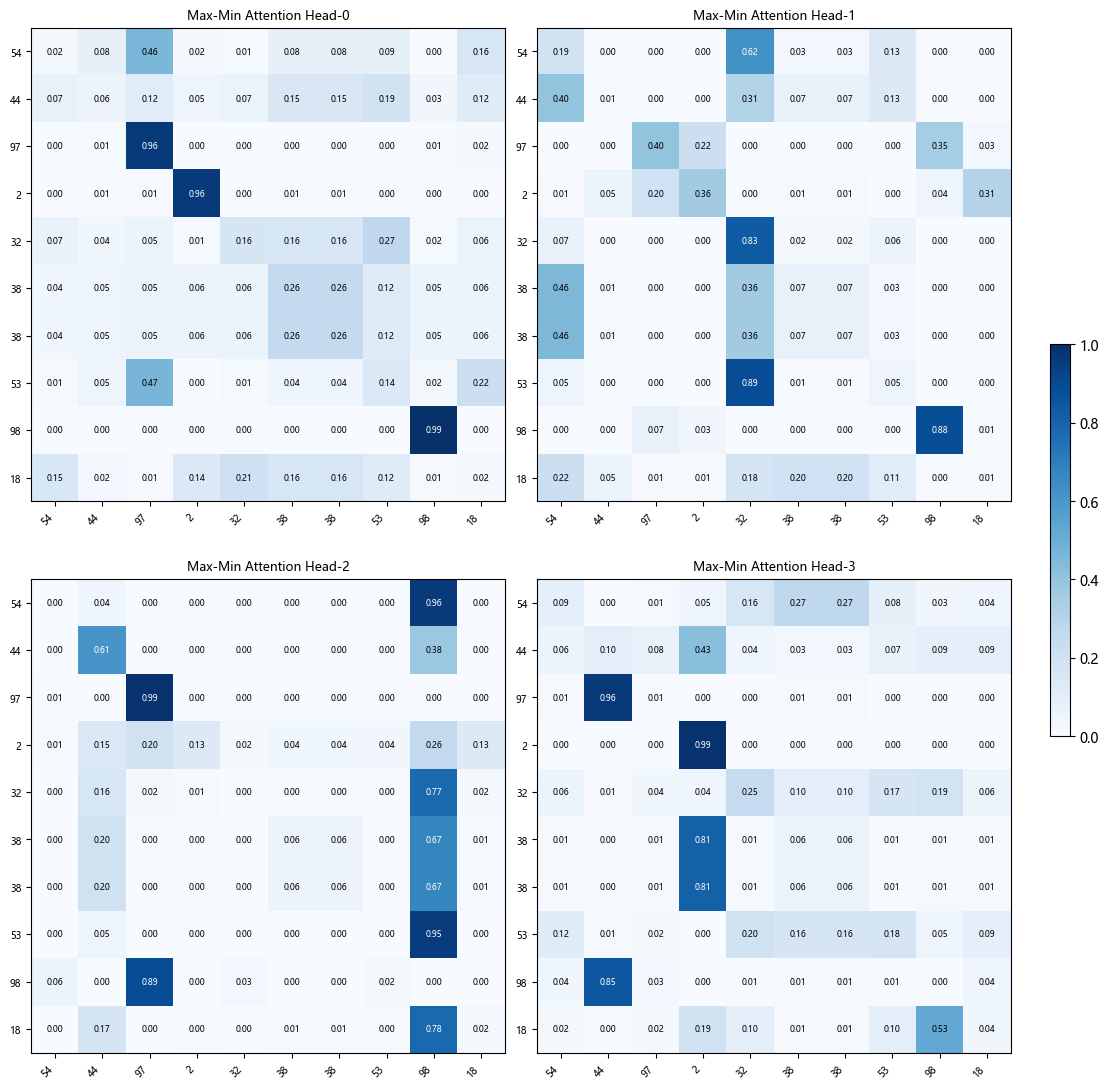

In [9]:
model.eval()
with torch.no_grad():
    eval_x, eval_y = get_batch_max_min(1024, 10, 1, 100)
    eval_pred = model(eval_x)  # (batch, seq_len, 2)

    eval_pred_max = eval_pred[:, :, 0].argmax(dim=-1).cpu().numpy()
    eval_pred_min = eval_pred[:, :, 1].argmax(dim=-1).cpu().numpy()
    eval_y_max = eval_y[:, 0].cpu().numpy()
    eval_y_min = eval_y[:, 1].cpu().numpy()

    print("MAX task")
    print(classification_report(eval_y_max, eval_pred_max, digits=4, zero_division=0))

    print("MIN task")
    print(classification_report(eval_y_min, eval_pred_min, digits=4, zero_division=0))

    test_x, test_y = get_batch_max_min(4, 10, 1, 100)
    
    pred = model(test_x)
    pred_max = pred[:, :, 0].argmax(dim=-1)
    pred_min = pred[:, :, 1].argmax(dim=-1)

    for i in range(test_x.size(0)):
        print(f"input : {test_x[i].tolist()}")
        print(f"pred  : [max={pred_max[i].item()}, min={pred_min[i].item()}]")
        print(f"target: [max={test_y[i,0].item()}, min={test_y[i,1].item()}]")
        print("-" * 30)
    
    sample_idx = 0
    sample_tokens = [str(v) for v in test_x[sample_idx].tolist()]
    plot_attention(model.attn_w[sample_idx], tokens=sample_tokens, title="Max-Min Attention")


将结果与单头注意力的评估结果做对比, 可以看出在 `num_heads=4` 时似乎是比单头注意力稍好一些的

事实上我最初尝试找出一个实验证明多头比单头优越在哪, 是否存在多头注意力显著优于单头头注意力的实验环境, 但是经过实验设计尝试后以失败告终, 在我构造的简单数据集上两者的效果差不多.

回看原论文时发现作者也没把这一点证明为强结论, 结合其他论文分析[2], 发现实践中可以去除很大一部分注意力头而不会对性能产生显著影响.

因此我倾向认为多头注意力有价值, 但是在简单实验中未必显著领先.

[2]: https://arxiv.org/abs/1905.10650 Michel et al., *Are Sixteen Heads Really Better than One?*, 2019.

# 实验2 指针检索任务

## 1. 数据集构建

1. 先生成一个随机序列 seq, 长度为 seq_len, 元素取值在 [0, vocab_size-1]
2. 再随机生成一个位置下标 idx, 范围是 [0, seq_len-1]
3. 构造一个查询标记 Q(这里用的是 vocab_size 这个特殊 id)
4. 把输入拼成：[seq, Q, idx], 所以实际输入长度是 seq_len + 2
5. 标签 y 定义为 seq[idx], 也就是"取出原序列中 idx 指向的位置值"

实验目标: 检验多头自注意力模型能否学会位置相关的任务

In [6]:
def get_seq_batch(batch, seq_len, vocab_size):
    seq = torch.randint(0, vocab_size, (batch, seq_len), dtype=torch.long)
    idx = torch.randint(0, seq_len, (batch,), dtype=torch.long)
    Q = torch.full((batch, 1), vocab_size, dtype=torch.long)  # 目标 token 是 vocab_size（即 high）这个特殊 token
    x = torch.cat([seq, Q, idx.unsqueeze(1)], dim=1)  # (batch, seq_len)
    y = seq[torch.arange(batch), idx]
    return x, y

In [7]:
epochs = 200

model = MultiHeadAttention(vocab_size=100, output_dim=10, d_model=32, num_heads=4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

model.train()
for i in range(epochs):
    train_x, train_y = get_seq_batch(1024, 10, 10)
    optimizer.zero_grad()
    pred = model(train_x)[:, -1, :]
    loss = criterion(pred, train_y)
    loss.backward()
    optimizer.step()
    if (i+1) % 10 == 0:
        print(f"Epoch {i+1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 2.0923
Epoch 20, Loss: 1.9385
Epoch 30, Loss: 1.9640
Epoch 40, Loss: 1.9012
Epoch 50, Loss: 1.9162
Epoch 60, Loss: 1.9237
Epoch 70, Loss: 1.9185
Epoch 80, Loss: 1.9203
Epoch 90, Loss: 1.9586
Epoch 100, Loss: 1.9267
Epoch 110, Loss: 1.8627
Epoch 120, Loss: 1.9341
Epoch 130, Loss: 1.8787
Epoch 140, Loss: 1.9181
Epoch 150, Loss: 1.9111
Epoch 160, Loss: 1.9162
Epoch 170, Loss: 1.8710
Epoch 180, Loss: 1.9391
Epoch 190, Loss: 1.8814
Epoch 200, Loss: 1.8716


## 3. 评估实验

不用评估了, 显然就是没有收敛. 这其实是符合预期的, 当前模型并不知道每个 token 的**位置**.

回顾其结构, 由于每个 token 都能直接看到其他任意的 token, 因此 token 本身的顺序关系便无了. 因此 1 2 3 和 3 2 1 在模型眼中是一样的.

那么如何给其加上位置信息呢? 下一章我们将引入位置编码解决这一问题.